# Notebook 06 — Squad Optimizer (v2)
## IPL 2027 Franchise Squad Predictor

**Fixes from v1:**
- Availability filter (no retired players)
- Minimum 2 pace bowlers in XI
- Minimum 4 bowling options in XI
- Max 2 overseas batsmen
- At least 1 spinner

## Step 0 — Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os

from pulp import (
    LpProblem, LpMaximize, LpVariable, lpSum,
    LpBinary, value, PULP_CBC_CMD
)

# ── UPDATE THESE PATHS ────────────────────────────────────────────
PROCESSED_DIR = r'E:/My ML Projects/2027 cricket squad prediction/data/processed/'
RAW_DIR       = r'E:/My ML Projects/2027 cricket squad prediction/data/raw/'
# ─────────────────────────────────────────────────────────────────

combined     = pd.read_parquet(PROCESSED_DIR + 'processedcombined_player_scores.parquet')
auction_pool = pd.read_csv(RAW_DIR + 'auction_pool_2027.csv')
raw          = pd.read_csv(RAW_DIR + 'ipl_ball_by_ball_clean.csv', low_memory=False)
raw['season'] = raw['season'].astype(str).str[:4].astype(int)
raw = raw[raw['season'].between(2016, 2025)]

print(f'Combined players : {len(combined)}')
print(f'Auction pool     : {len(auction_pool)} ({auction_pool["available"].sum()} available)')
print(f'Raw deliveries   : {len(raw):,}')

Combined players : 486
Auction pool     : 135 (113 available)
Raw deliveries   : 155,703


## Step 1 — Role Classification + Availability Filter

In [5]:
AR_MIN_MATCHES = 10

bat_counts  = raw.groupby('batter')['match_id'].nunique().reset_index()
bat_counts.columns  = ['player', 'matches_batted']
bowl_counts = raw.groupby('bowler')['match_id'].nunique().reset_index()
bowl_counts.columns = ['player', 'matches_bowled']
participation = bat_counts.merge(bowl_counts, on='player', how='outer').fillna(0)

pool = combined.merge(participation, on='player', how='left')
pool['matches_batted']  = pool['matches_batted'].fillna(0)
pool['matches_bowled']  = pool['matches_bowled'].fillna(0)

def classify_role(row):
    bat_ok  = row['matches_batted']  >= AR_MIN_MATCHES and pd.notna(row.get('bat_win_prob'))
    bowl_ok = row['matches_bowled'] >= AR_MIN_MATCHES and pd.notna(row.get('bowl_win_prob'))
    if bat_ok and bowl_ok:
        return 'AR'
    elif bat_ok:
        return 'BAT'
    elif bowl_ok:
        return 'BOWL'
    else:
        return 'UNKNOWN'

pool['role'] = pool.apply(classify_role, axis=1)
pool = pool[pool['role'] != 'UNKNOWN'].copy()

# Availability filter
available_players = set(auction_pool[auction_pool['available'] == 1]['player_name'])
pool = pool[pool['player'].isin(available_players)].copy()

# Merge bowling_type and nationality
pool = pool.merge(
    auction_pool[['player_name','bowling_type','nationality']],
    left_on='player', right_on='player_name', how='left'
).drop(columns=['player_name'])
pool['bowling_type'] = pool['bowling_type'].fillna('BAT')

print(f'After availability filter : {len(pool)} players')
print(f'Role breakdown            : {pool["role"].value_counts().to_dict()}')
print(f'Bowling type breakdown    : {pool["bowling_type"].value_counts().to_dict()}')

After availability filter : 105 players
Role breakdown            : {'AR': 48, 'BAT': 39, 'BOWL': 18}
Bowling type breakdown    : {'PACE': 31, 'BAT': 30, 'AR': 23, 'SPIN': 11, 'WK': 10}


## Step 2 — Wicketkeeper Flag

In [6]:
KNOWN_KEEPERS = {
    'MS Dhoni','KL Rahul','RR Pant','Q de Kock','JC Buttler',
    'WP Saha','PD Salt','Ishan Kishan','KS Bharat','N Pooran',
    'SV Samson','KD Karthik','Dhruv Jurel','H Klaasen','JM Bairstow',
}

pool['is_wk'] = pool['player'].isin(KNOWN_KEEPERS).astype(int)
pool.loc[pool['is_wk']==1,'role'] = pool.loc[pool['is_wk']==1,'role'].replace({'BAT':'WK','AR':'WK-AR'})

print(f'Keepers in pool : {pool[pool["is_wk"]==1]["player"].tolist()}')
print(f'Role distribution:')
print(pool['role'].value_counts())

Keepers in pool : ['Dhruv Jurel', 'H Klaasen', 'Ishan Kishan', 'JM Bairstow', 'KL Rahul', 'N Pooran', 'PD Salt', 'Q de Kock', 'RR Pant', 'SV Samson']
Role distribution:
role
AR      48
BAT     29
BOWL    18
WK      10
Name: count, dtype: int64


## Step 3 — Age Decay

In [7]:
first_season = raw.groupby('batter')['season'].min().reset_index()
first_season.columns = ['player','first_season']
pool = pool.merge(first_season, on='player', how='left')
pool['first_season'] = pool['first_season'].fillna(2020)

def age_decay(fs):
    if fs >= 2020: return 1.00
    elif fs >= 2016: return 0.95
    else: return 0.85

pool['age_decay_factor'] = pool['first_season'].apply(age_decay)
pool['adjusted_score']   = pool['combined_score'] * pool['age_decay_factor']
print('Age decay applied.')
print(pool.groupby('age_decay_factor')['player'].count())

Age decay applied.
age_decay_factor
0.95    66
1.00    39
Name: player, dtype: int64


## Step 4 — Overseas Flag

In [8]:
pool['is_overseas'] = (pool['nationality'] != 'Indian').astype(int)
print(f'Overseas : {pool["is_overseas"].sum()}  |  Indian : {(pool["is_overseas"]==0).sum()}')

Overseas : 40  |  Indian : 65


## Step 5 — Optimizer Function

In [9]:
def select_xi(player_pool, n_players=11, max_overseas=4, verbose=True):
    df  = player_pool.reset_index(drop=True).copy()
    n   = len(df)
    idx = range(n)

    prob = LpProblem('IPL_Best_XI', LpMaximize)
    x    = [LpVariable(f'x_{i}', cat=LpBinary) for i in idx]

    prob += lpSum(df.loc[i,'adjusted_score'] * x[i] for i in idx)

    wk_i   = [i for i in idx if df.loc[i,'role'] in ('WK','WK-AR')]
    bat_i  = [i for i in idx if df.loc[i,'role'] in ('BAT','WK','WK-AR')]
    bowl_i = [i for i in idx if df.loc[i,'role'] in ('BOWL','AR','WK-AR')]
    ar_i   = [i for i in idx if df.loc[i,'role'] in ('AR','WK-AR')]
    ov_i   = [i for i in idx if df.loc[i,'is_overseas'] == 1]
    ov_bat = [i for i in idx if df.loc[i,'is_overseas']==1 and df.loc[i,'role'] in ('BAT','WK','WK-AR')]
    pace_i = [i for i in idx if df.loc[i,'bowling_type'] == 'PACE']
    spin_i = [i for i in idx if df.loc[i,'bowling_type'] == 'SPIN']

    prob += lpSum(x[i] for i in idx) == n_players
    if wk_i:
        prob += lpSum(x[i] for i in wk_i) >= 1
        prob += lpSum(x[i] for i in wk_i) <= 2
    prob += lpSum(x[i] for i in bat_i)  >= 3
    prob += lpSum(x[i] for i in bat_i)  <= 6
    prob += lpSum(x[i] for i in bowl_i) >= 4
    prob += lpSum(x[i] for i in bowl_i) <= 7
    if ar_i:   prob += lpSum(x[i] for i in ar_i)   >= 1
    prob += lpSum(x[i] for i in ov_i)   <= max_overseas
    if ov_bat: prob += lpSum(x[i] for i in ov_bat) <= 2
    if len(pace_i) >= 2: prob += lpSum(x[i] for i in pace_i) >= 2
    if spin_i: prob += lpSum(x[i] for i in spin_i) >= 1

    prob.solve(PULP_CBC_CMD(msg=0))
    selected = df[[value(x[i])==1 for i in idx]].copy()
    selected = selected.sort_values('adjusted_score', ascending=False)

    if verbose:
        print(f'Solver status        : {prob.status} (1=Optimal)')
        print(f'Total adjusted score : {selected["adjusted_score"].sum():.4f}')
        print(f'Overseas selected    : {selected["is_overseas"].sum()}')
        print(f'Pace bowlers         : {(selected["bowling_type"]=="PACE").sum()}')
        print(f'Spin bowlers         : {(selected["bowling_type"]=="SPIN").sum()}')
    return selected

print('Optimizer defined.')

Optimizer defined.


## Step 6 — Run XI Optimizer

In [10]:
eligible = pool[(pool['role']!='UNKNOWN') & (pool['adjusted_score'].notna()) & (pool['adjusted_score']>0)].copy()
print(f'Eligible pool : {len(eligible)} players\n')

best_xi = select_xi(eligible)

print()
print('='*68)
print('         PREDICTED BEST XI — IPL 2027')
print('='*68)
print(f'{"Player":<25} {"Role":<8} {"Type":<8} {"OVS":<5} {"Score":>7}')
print('-'*68)
for _, row in best_xi.iterrows():
    ovs   = 'OVS' if row['is_overseas']==1 else 'IND'
    btype = row.get('bowling_type','-')
    print(f"{row['player']:<25} {row['role']:<8} {btype:<8} {ovs:<5} {row['adjusted_score']:>7.3f}")
print('='*68)

Eligible pool : 105 players

Solver status        : 1 (1=Optimal)
Total adjusted score : 6.9511
Overseas selected    : 4
Pace bowlers         : 4
Spin bowlers         : 1

         PREDICTED BEST XI — IPL 2027
Player                    Role     Type     OVS     Score
--------------------------------------------------------------------
RR Rossouw                BAT      BAT      OVS     0.874
B Sai Sudharsan           BAT      BAT      IND     0.869
J Little                  BOWL     PACE     OVS     0.843
H Klaasen                 WK       WK       OVS     0.745
JM Sharma                 BAT      PACE     IND     0.688
Dhruv Jurel               WK       WK       IND     0.660
SS Iyer                   BAT      BAT      IND     0.501
MR Marsh                  AR       AR       OVS     0.479
Akash Singh               BOWL     PACE     IND     0.477
JD Unadkat                AR       PACE     IND     0.439
R Ashwin                  AR       SPIN     IND     0.376


## Step 7 — 25-Player Squad

In [11]:
def select_squad(player_pool, squad_size=25, max_overseas=8):
    df  = player_pool.reset_index(drop=True).copy()
    n   = len(df)
    idx = range(n)
    prob = LpProblem('IPL_Squad_25', LpMaximize)
    x    = [LpVariable(f'x_{i}', cat=LpBinary) for i in idx]
    prob += lpSum(df.loc[i,'adjusted_score'] * x[i] for i in idx)
    wk_i   = [i for i in idx if df.loc[i,'role'] in ('WK','WK-AR')]
    bat_i  = [i for i in idx if df.loc[i,'role'] in ('BAT','WK','WK-AR')]
    bowl_i = [i for i in idx if df.loc[i,'role'] in ('BOWL','AR','WK-AR')]
    ar_i   = [i for i in idx if df.loc[i,'role'] in ('AR','WK-AR')]
    ov_i   = [i for i in idx if df.loc[i,'is_overseas']==1]
    pace_i = [i for i in idx if df.loc[i,'bowling_type']=='PACE']
    prob += lpSum(x[i] for i in idx)    == squad_size
    prob += lpSum(x[i] for i in wk_i)  >= 2
    prob += lpSum(x[i] for i in wk_i)  <= 4
    prob += lpSum(x[i] for i in bat_i) >= 7
    prob += lpSum(x[i] for i in bowl_i)>= 9
    prob += lpSum(x[i] for i in ar_i)  >= 2
    prob += lpSum(x[i] for i in ov_i)  <= max_overseas
    if len(pace_i)>=4: prob += lpSum(x[i] for i in pace_i) >= 4
    prob.solve(PULP_CBC_CMD(msg=0))
    selected = df[[value(x[i])==1 for i in idx]].copy()
    return selected.sort_values(['role','adjusted_score'],ascending=[True,False])

squad_25 = select_squad(eligible)
print('='*68)
print('         RECOMMENDED 25-PLAYER SQUAD — IPL 2027')
print('='*68)
print(f'{"#":>3}  {"Player":<25} {"Role":<8} {"Type":<8} {"OVS":<5} {"Score":>6}')
print('-'*68)
for i,(_, row) in enumerate(squad_25.iterrows(),1):
    ovs   = 'OVS' if row['is_overseas']==1 else 'IND'
    btype = row.get('bowling_type','-')
    print(f"{i:>3}.  {row['player']:<25} {row['role']:<8} {btype:<8} {ovs:<5} {row['adjusted_score']:>6.3f}")
print('='*68)
print(f'Overseas: {squad_25["is_overseas"].sum()}/8  |  Roles: {squad_25["role"].value_counts().to_dict()}')

         RECOMMENDED 25-PLAYER SQUAD — IPL 2027
  #  Player                    Role     Type     OVS    Score
--------------------------------------------------------------------
  1.  MR Marsh                  AR       AR       OVS    0.479
  2.  C Green                   AR       AR       OVS    0.451
  3.  JD Unadkat                AR       PACE     IND    0.439
  4.  KH Pandya                 AR       AR       IND    0.389
  5.  R Ashwin                  AR       SPIN     IND    0.376
  6.  Kuldeep Yadav             AR       SPIN     IND    0.362
  7.  AR Patel                  AR       AR       IND    0.359
  8.  S Dube                    AR       AR       IND    0.339
  9.  Abhishek Sharma           AR       BAT      IND    0.294
 10.  RR Rossouw                BAT      BAT      OVS    0.874
 11.  B Sai Sudharsan           BAT      BAT      IND    0.869
 12.  JM Sharma                 BAT      PACE     IND    0.688
 13.  JJ Roy                    BAT      BAT      OVS    0.575
 1

## Step 8 — Visualise

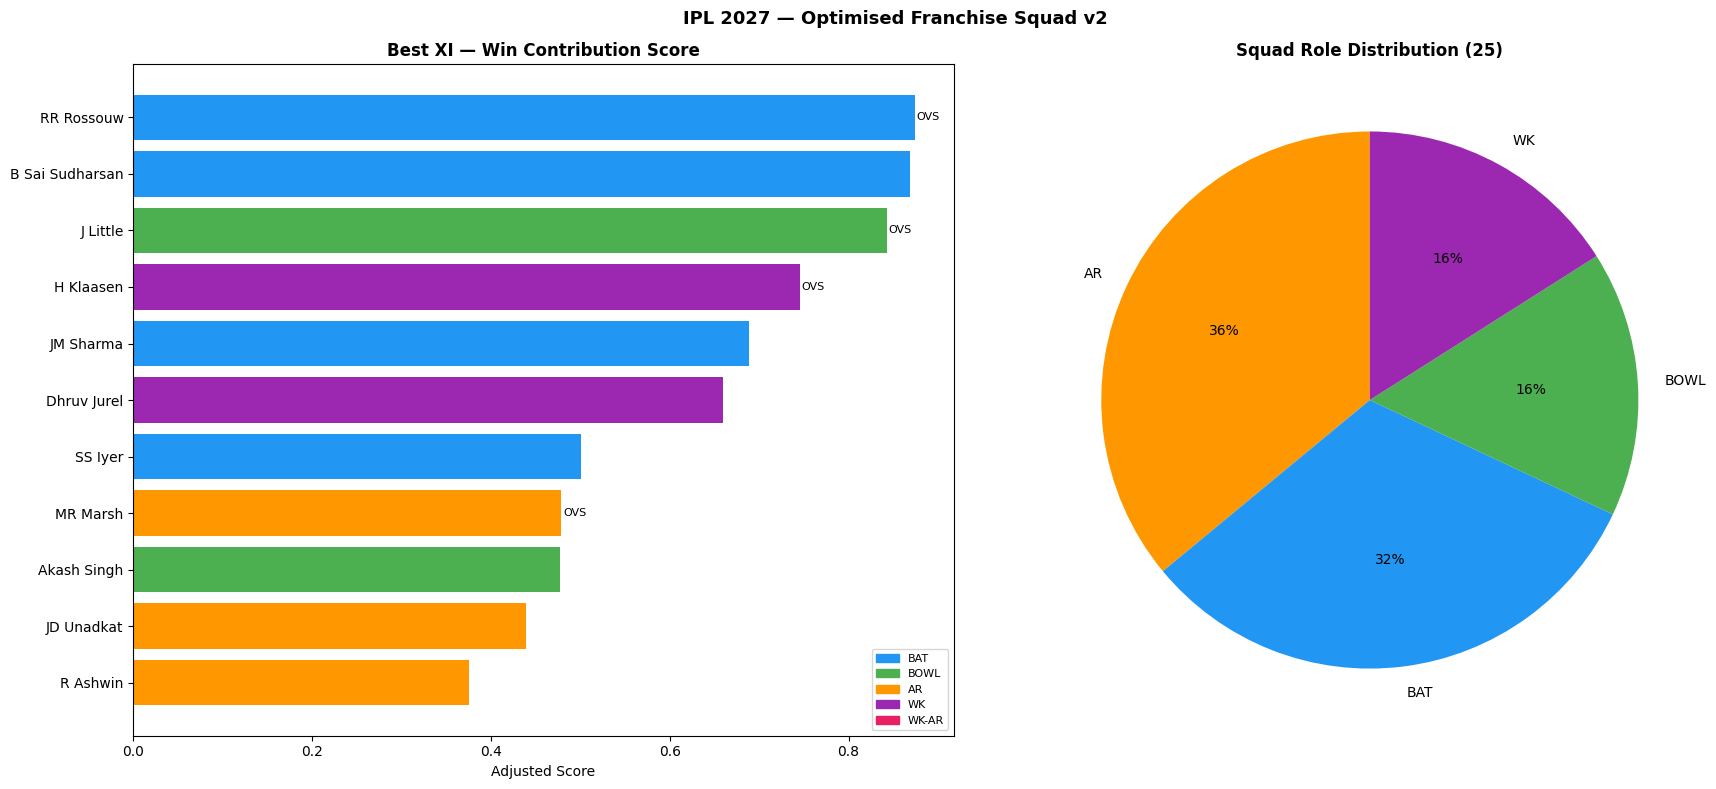

Plot saved.


In [12]:
from matplotlib.patches import Patch
ROLE_COLORS = {'BAT':'#2196F3','BOWL':'#4CAF50','AR':'#FF9800','WK':'#9C27B0','WK-AR':'#E91E63'}
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
bar_colors = [ROLE_COLORS.get(r,'#607D8B') for r in best_xi['role']]
bars = axes[0].barh(best_xi['player'], best_xi['adjusted_score'], color=bar_colors)
for bar,(_, row) in zip(bars, best_xi.iterrows()):
    if row['is_overseas']==1:
        axes[0].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, 'OVS', va='center', fontsize=8)
axes[0].set_title('Best XI — Win Contribution Score', fontweight='bold')
axes[0].set_xlabel('Adjusted Score')
axes[0].invert_yaxis()
axes[0].legend(handles=[Patch(color=v,label=k) for k,v in ROLE_COLORS.items()], loc='lower right', fontsize=8)
role_counts = squad_25['role'].value_counts()
pie_colors  = [ROLE_COLORS.get(r,'#607D8B') for r in role_counts.index]
axes[1].pie(role_counts.values, labels=role_counts.index, colors=pie_colors, autopct='%1.0f%%', startangle=90)
axes[1].set_title('Squad Role Distribution (25)', fontweight='bold')
plt.suptitle('IPL 2027 — Optimised Franchise Squad v2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR + 'squad_selection_v2.png', dpi=120)
plt.show()
print('Plot saved.')

## Step 9 — Save

In [13]:
best_xi.to_parquet(PROCESSED_DIR+'best_xi.parquet', index=False)
best_xi.to_csv(PROCESSED_DIR+'best_xi.csv', index=False)
squad_25.to_parquet(PROCESSED_DIR+'squad_25.parquet', index=False)
squad_25.to_csv(PROCESSED_DIR+'squad_25.csv', index=False)
print('Saved: best_xi.csv + squad_25.csv')

Saved: best_xi.csv + squad_25.csv


## Step 10 — Validation Checks

In [14]:
pace_in_xi = (best_xi['bowling_type']=='PACE').sum()
spin_in_xi = (best_xi['bowling_type']=='SPIN').sum()
bowl_in_xi = best_xi['role'].isin(['BOWL','AR','WK-AR']).sum()
ov_bat_xi  = ((best_xi['is_overseas']==1) & (best_xi['role'].isin(['BAT','WK']))).sum()

checks = [
    ('Best XI has exactly 11 players',       len(best_xi)==11),
    ('Squad has exactly 25 players',         len(squad_25)==25),
    ('Best XI overseas <= 4',                best_xi['is_overseas'].sum()<=4),
    ('Squad overseas <= 8',                  squad_25['is_overseas'].sum()<=8),
    ('Best XI has at least 1 WK',            best_xi['role'].isin(['WK','WK-AR']).sum()>=1),
    ('Best XI has at least 4 bowling opts',  bowl_in_xi>=4),
    ('Best XI has at least 3 batters',       best_xi['role'].isin(['BAT','WK','WK-AR']).sum()>=3),
    ('Best XI has at least 2 pace bowlers',  pace_in_xi>=2),
    ('Best XI has at least 1 spinner',       spin_in_xi>=1),
    ('Max 2 overseas batsmen in XI',         ov_bat_xi<=2),
    ('No retired: Malinga',                  'SL Malinga' not in best_xi['player'].values),
    ('No retired: Dhoni',                    'MS Dhoni' not in best_xi['player'].values),
    ('No retired: Gayle',                    'CH Gayle' not in best_xi['player'].values),
    ('best_xi.csv saved',                    os.path.exists(PROCESSED_DIR+'best_xi.csv')),
    ('squad_25.csv saved',                   os.path.exists(PROCESSED_DIR+'squad_25.csv')),
]

all_pass = True
for name, result in checks:
    icon = '✓' if result else '✗  FAIL'
    print(f'{icon}  {name}')
    if not result: all_pass = False

print(f'\n  Pace bowlers in XI  : {pace_in_xi}')
print(f'  Spin bowlers in XI  : {spin_in_xi}')
print(f'  Bowling options     : {bowl_in_xi}')
print(f'  Overseas batsmen    : {ov_bat_xi}')
print()
if all_pass:
    print('All checks passed. Phase 1 COMPLETE.')
    print('Next: Phase 2 — FastAPI + Streamlit deployment.')
else:
    print('Fix failing checks before proceeding.')

✓  Best XI has exactly 11 players
✓  Squad has exactly 25 players
✓  Best XI overseas <= 4
✓  Squad overseas <= 8
✓  Best XI has at least 1 WK
✓  Best XI has at least 4 bowling opts
✓  Best XI has at least 3 batters
✓  Best XI has at least 2 pace bowlers
✓  Best XI has at least 1 spinner
✓  Max 2 overseas batsmen in XI
✓  No retired: Malinga
✓  No retired: Dhoni
✓  No retired: Gayle
✓  best_xi.csv saved
✓  squad_25.csv saved

  Pace bowlers in XI  : 4
  Spin bowlers in XI  : 1
  Bowling options     : 5
  Overseas batsmen    : 2

All checks passed. Phase 1 COMPLETE.
Next: Phase 2 — FastAPI + Streamlit deployment.
